In [13]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = "MSFT.csv"  # Update path if necessary
df = pd.read_csv(file_path)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

# Create target variable: 1 if next day's return > 0, else 0
df['return'] = df['close'].pct_change()
df['target'] = (df['return'].shift(-1) > 0).astype(int)

# Feature: Moving Averages
df['ma_5'] = df['close'].rolling(window=5).mean()
df['ma_10'] = df['close'].rolling(window=10).mean()
df['ma_50'] = df['close'].rolling(window=50).mean()
df['ma_200'] = df['close'].rolling(window=200).mean()

# Feature: Volatility (Rolling Std Dev)
df['std_5'] = df['close'].rolling(window=5).std()
df['std_10'] = df['close'].rolling(window=10).std()
df['std_20'] = df['close'].rolling(window=20).std()

# Feature: Volume dynamics
df['volume_change'] = df['volume'].pct_change()
df['volume_ma_5'] = df['volume'].rolling(window=5).mean()

# Feature: Price Gaps
df['price_gap'] = df['close'] - df['open']

# Feature: Relative position to MA50
df['close_to_ma50'] = (df['close'] - df['ma_50']) / df['ma_50']

# Volatility regime flag (high volatility periods)
df['volatility_regime'] = (df['std_10'] > df['std_10'].mean()).astype(int)

# Calendar features
df['weekday'] = df['date'].dt.weekday  # 0 = Monday, 6 = Sunday
df['month'] = df['date'].dt.month

# Drop rows with NaNs due to rolling windows
df_clean = df.dropna().reset_index(drop=True)

# Final Feature Set
feature_cols = [
    'ma_5', 'ma_10', 'ma_50', 'ma_200',
    'std_5', 'std_10', 'std_20',
    'volume_change', 'volume_ma_5',
    'price_gap', 'close_to_ma50',
    'volatility_regime', 'weekday', 'month'
]

# Features (X) and Target (y)
X = df_clean[feature_cols]
y = df_clean['target']

# Confirm shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (9670, 14)
Target shape: (9670,)


Top 10 Most Highly Correlated Feature Pairs:
   Feature 1 Feature 2  Correlation
0       ma_5     ma_10     0.999873
13     ma_10      ma_5     0.999873
27     ma_50     ma_10     0.998793
14     ma_10     ma_50     0.998793
26     ma_50      ma_5     0.998436
1       ma_5     ma_50     0.998436
41    ma_200     ma_50     0.996096
28     ma_50    ma_200     0.996096
40    ma_200     ma_10     0.993356
15     ma_10    ma_200     0.993356


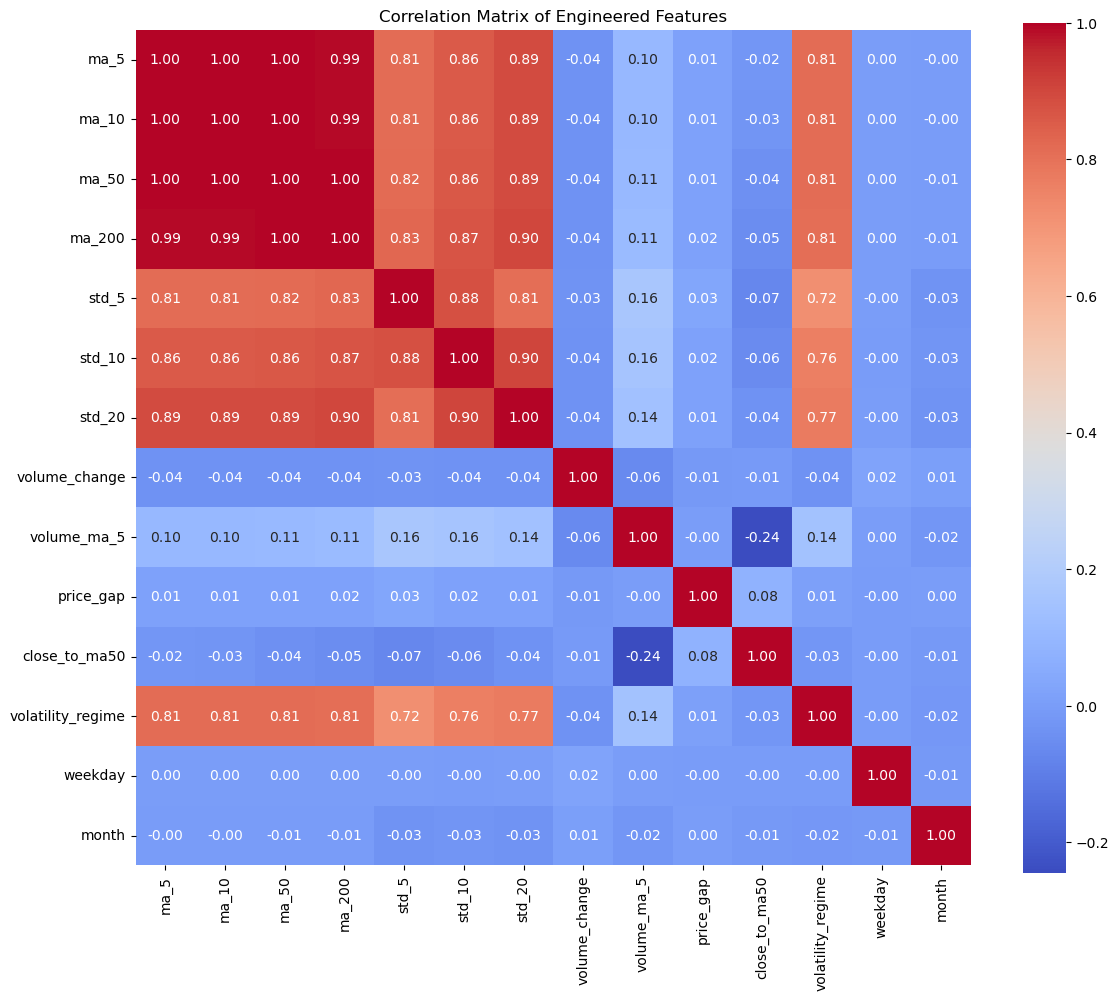

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assume X is your DataFrame containing the engineered features
# Compute correlation matrix
correlation_matrix = X.corr()

# Display top correlations in text format (excluding the diagonal)
mask = ~np.eye(correlation_matrix.shape[0], dtype=bool)
correlation_pairs = correlation_matrix.where(mask).stack().reset_index()
correlation_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
correlation_pairs['AbsCorrelation'] = correlation_pairs['Correlation'].abs()

# Sort by absolute correlation value
top_correlations = correlation_pairs.sort_values(by='AbsCorrelation', ascending=False).head(10)

# Print top correlated pairs
print("Top 10 Most Highly Correlated Feature Pairs:")
print(top_correlations[['Feature 1', 'Feature 2', 'Correlation']])

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Engineered Features")
plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed dataset
df = pd.read_csv("MSFT.csv", parse_dates=['date'])

# Sort and preprocess
df = df.sort_values('date')
df['daily_return'] = df['close'].pct_change()
df['ma_10'] = df['close'].rolling(window=10).mean()
df['ma_200'] = df['close'].rolling(window=200).mean()
df['std_10'] = df['close'].rolling(window=10).std()
df['std_20'] = df['close'].rolling(window=20).std()
df['volume_change'] = df['volume'].pct_change()
df['volume_ma_5'] = df['volume'].rolling(window=5).mean()
df['price_gap'] = df['close'] - df['open']
df['close_to_ma50'] = (df['close'] - df['close'].rolling(window=50).mean()) / df['close'].rolling(window=50).mean()
df['volatility_regime'] = (df['std_10'] > df['std_10'].mean()).astype(int)
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

# Drop NA after rolling operations
df.dropna(inplace=True)

# Step 1: Correlation Filtering (optional)
corr_matrix = df[['ma_10', 'ma_200', 'std_10', 'std_20',
                  'volume_change', 'volume_ma_5', 'price_gap',
                  'close_to_ma50', 'volatility_regime', 'weekday', 'month']].corr()

# Visualize correlation heatmap (optional)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Candidate Features")
plt.tight_layout()
plt.savefig('Feature_Selection_Correlation_Matrix.png')
plt.close()

# Step 2: Random Forest Feature Importance
feature_cols = ['ma_10', 'ma_200', 'std_10', 'std_20', 'volume_change', 'volume_ma_5',
                'price_gap', 'close_to_ma50', 'volatility_regime', 'weekday', 'month']

X = df[feature_cols]
y = df['target']

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('Feature_Importance_Barplot.png')
plt.close()

# Print final ranked features
print("Top Features (Random Forest):")
print(importance_df)


Top Features (Random Forest):
              Feature  Importance
4       volume_change    0.121479
7       close_to_ma50    0.116080
6           price_gap    0.113580
2              std_10    0.113317
5         volume_ma_5    0.113161
3              std_20    0.109863
1              ma_200    0.105229
0               ma_10    0.104718
10              month    0.057509
9             weekday    0.042661
8   volatility_regime    0.002404
